<a href="https://colab.research.google.com/github/iamatulkumar-ya/data-science/blob/master/libraries/langchain/langgraph/langgraph_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LangGraph

## LangGraph Intro and Basic Flow

Let's learn basic around creating an agent/flow using LangGraph

LangGraph: <i>LangGraph is an open-source framework from the makers of LangChain that builds complex, multi-step AI agent workflows using a graph-based structure. It's used to orchestrate how different components, like LLMs and tools, interact and make decisions, enabling more sophisticated applications beyond simple linear chains. It's particularly useful for creating agents that require state, branching logic, or human-in-the-loop interventions </i>

Documents:


*   https://docs.langchain.com/oss/python/langgraph/quickstart
*   https://docs.langchain.com/oss/python/langgraph/graph-api



In [ ]:
%%capture
!pip install langgraph
!pip install mermaid-py # lib for graph structure visualization

<b>State:</b> A shared data structure that represents the current snapshot of your application. It can be any data type, but is typically defined using a shared state schema.

<b>Nodes:</b> Functions that encode the logic of your agents. They receive the current state as input, perform some computation or side-effect, and return an updated state.

<b>Edges:</b> Functions that determine which Node to execute next based on the current state. They can be conditional branches or fixed transitions.

Creating functions to act as a node functionality

In [ ]:
def first_node(state:str):
  return state + " first node response."

In [ ]:
def second_node(state:str):
  return state + " Adding second node response."

In [ ]:
# defining grpah
# Stategraph is used to typed the output and share the state vars across multiple nodes
from langgraph.graph import StateGraph, END
# Using below lib for graph structure to visualize
import mermaid as md
# Below is the lib to render the image
from IPython.display import Image

In [ ]:
workflow = StateGraph(dict)  # we must set schema, if we do not have any then we can set to dict

adding nodes

In [ ]:
workflow.add_node("first_node", first_node)
workflow.add_node("second_node", second_node)

Creating edges, to connect two nodes

In [ ]:
workflow.add_edge("first_node", "second_node")

Setting entry point and finish point for the graph

In [ ]:
workflow.set_entry_point("first_node")
workflow.set_finish_point("second_node")

Let's compile and invoke

In [ ]:
app = workflow.compile()

In [ ]:
app.invoke("Getting the response from ")

'Getting the response from  first node response. Adding second node response.'

let's view the graph structure

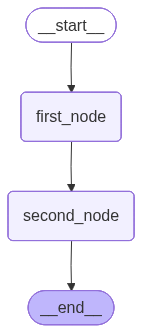

In [ ]:
display(Image(app.get_graph().draw_mermaid_png()))

Perfect!!!!!

Here is the simple agent, that takes the input and executes the request with specified steps one after another (first node -> second node).

## Conditional Routing between Nodes

Let's see how we can do conditional routing between nodes on the basis of some conditions.

In [ ]:
from typing import TypedDict, Annotated
from IPython.core.compilerop import operator

In [ ]:

# creating a custom class for graph state, which will maintain the state between the  flow. We could also use MessageState inbuilt class
class AgentState(TypedDict):
  messages : Annotated[list, operator.add]  # declared the dict with annotated that each item get added as arrives

In [ ]:
# creating various functions which will represent the nodes
import random
def agent_node(agentState: AgentState):
  # here we can fetch the current state of the flow to make decisions
  print("\nInside Agent Node ", agentState)
  nextCall = "RAG" if (random.randint(1,9))%2 == 0 else "LLM"
  return {'messages' : [f"Agent call completed. Proceed with {nextCall}"]}


def rag_node(agentState: AgentState):
  # here we can fetch the current state of the flow to make decisions
  print("\nInside RAG Node ", agentState)
  return {'messages' : ['This is the RAG response. RAG call completed']}


def llm_node(agentState: AgentState):
  # here we can fetch the current state of the flow to make decisions
  print("\nInside LLM Node ", agentState)
  return {'messages' : ['This is LLM response. LLM call completed']}

In [ ]:
# defining the router

def router(agentState: AgentState):
  # let's fetch the recent message such that we can decide the route for next flow
  message = str(agentState["messages"][-1])

  if message.__contains__("RAG"):
    return "RAG Call"
  else:
    return "LLM Call"

In [ ]:
# defining the graph and adding nodes and edges

cGraph = StateGraph(AgentState)

cGraph.add_node("agent", agent_node)
cGraph.add_node("rag", rag_node)
cGraph.add_node("llm", llm_node)


In [ ]:
# now adding conditional edge and rest adges

cGraph.add_conditional_edges(
    "agent",
    router,
    {
        "RAG Call" : "rag",
        "LLM Call" : "llm"
    }
)


# let's end the flow once either rag or llm gets executed
cGraph.add_edge("rag", END)
cGraph.add_edge("llm", END)

In [ ]:
# let's compile and visualize  graph

cGraph.set_entry_point("agent")
cApp = cGraph.compile()


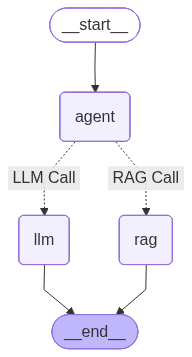

In [ ]:
display(Image(cApp.get_graph().draw_mermaid_png()))

Let's check the flow

In [ ]:
input_text = {"messages": ["What do you know about LangGraph?"]}
output = cApp.invoke(input_text)

print("\nCombined agent response", output)
print("\nfinal response - ", output["messages"][-1])


Inside Agent Node  {'messages': ['What do you know about LangGraph?']}

Inside LLM Node  {'messages': ['What do you know about LangGraph?', 'Agent call completed. Proceed with LLM']}

Combined agent response {'messages': ['What do you know about LangGraph?', 'Agent call completed. Proceed with LLM', 'This is LLM response. LLM call completed']}

final response -  This is LLM response. LLM call completed


Bingooo!!!! Nice progress. There are more things, let's continue with other jupyter notebooks.